# 03 Gap Diagnostics and Plotnine Figures

This notebook creates simple figures from measurement data dated **2026-05-29 onward only** and checks whether temperature patterns support overheating as a plausible explanation for missing data.

In [1]:
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import csv
import os
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

DATA_START_DATE = "20260615"
ANALYSIS_TIMEZONE = "Europe/Zurich"
ANALYSIS_RUN_DATE = pd.Timestamp(datetime.now(ZoneInfo(ANALYSIS_TIMEZONE)).date())
ANALYSIS_END_DATE = ANALYSIS_RUN_DATE.strftime("%Y%m%d")
ANALYSIS_MAX_TIME_EXCLUSIVE = ANALYSIS_RUN_DATE + pd.Timedelta(days=1)
EXPECTED_INTERVAL_SECONDS = 20
GPS_STALE_THRESHOLD_MS = 120000
DATA_DIR = Path("..") / "test_data"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
MPLCONFIG_DIR = FIG_DIR / ".mplconfig"
MPLCONFIG_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR.resolve()))

from plotnine import *

print("pandas", pd.__version__)
print("figures", FIG_DIR.resolve())
print("analysis date cutoff", ANALYSIS_RUN_DATE.date())

pandas 3.0.3
figures C:\Users\jonmuell\Documents\GitHub\datalogger_esp8266\test_analysis\figures
analysis date cutoff 2026-06-29


In [2]:
def data_file_date(path: Path) -> str:
    match = re.fullmatch(r"data_(\d{8})\.csv", path.name)
    return match.group(1) if match else ""


def unique_headers(headers: list[str]) -> list[str]:
    total = Counter(headers)
    seen = defaultdict(int)
    out = []
    for header in headers:
        if total[header] == 1:
            out.append(header)
        else:
            bus = seen[header]
            out.append(f"{header}__bus{bus}")
            seen[header] += 1
    return out


def measurement_files(data_dir: Path = DATA_DIR, start_date: str = DATA_START_DATE, end_date: str = ANALYSIS_END_DATE) -> list[Path]:
    return sorted(
        path for path in data_dir.glob("data_*.csv")
        if data_file_date(path) and start_date <= data_file_date(path) <= end_date
    )


def future_measurement_files(data_dir: Path = DATA_DIR, end_date: str = ANALYSIS_END_DATE) -> list[Path]:
    return sorted(path for path in data_dir.glob("data_*.csv") if data_file_date(path) and data_file_date(path) > end_date)


def csv_data_row_count(path: Path) -> int:
    with path.open("r", encoding="utf-8", errors="replace") as f:
        return max(sum(1 for _ in f) - 1, 0)


def read_measurement_file(path: Path) -> pd.DataFrame:
    with path.open("r", encoding="utf-8", newline="") as f:
        headers = next(csv.reader(f))
    names = unique_headers(headers)
    df = pd.read_csv(
        path,
        names=names,
        skiprows=1,
        na_values=["", "nan", "NaN", "NAN"],
        keep_default_na=True,
        on_bad_lines="skip",
    )
    df.insert(0, "source_file", path.name)
    df.insert(1, "source_date", data_file_date(path))
    return df


files = measurement_files()
future_files_excluded = future_measurement_files()
future_files_excluded_summary = pd.DataFrame([
    {"source_file": path.name, "source_date": data_file_date(path), "rows": csv_data_row_count(path), "first_time": pd.NaT, "last_time": pd.NaT}
    for path in future_files_excluded
])
if future_files_excluded_summary.empty:
    future_files_excluded_summary = pd.DataFrame(columns=["source_file", "source_date", "rows", "first_time", "last_time"])
assert all(DATA_START_DATE <= data_file_date(file) <= ANALYSIS_END_DATE for file in files)
data = pd.concat([read_measurement_file(file) for file in files], ignore_index=True)
data["timestamp_utc"] = pd.to_datetime(data["timestamp_utc"], errors="coerce")
if "timestamp_calc_utc" in data.columns:
    data["timestamp_calc_utc"] = pd.to_datetime(data["timestamp_calc_utc"], errors="coerce")
else:
    data["timestamp_calc_utc"] = pd.NaT
if "gps_time_fresh" in data.columns:
    data["gps_time_fresh_bool"] = pd.to_numeric(data["gps_time_fresh"], errors="coerce").fillna(1).astype(bool)
else:
    data["gps_time_fresh_bool"] = True
gps_age = pd.to_numeric(data["gps_age_ms"], errors="coerce") if "gps_age_ms" in data.columns else pd.Series(pd.NA, index=data.index, dtype="Float64")
data["gps_age_too_high"] = gps_age > GPS_STALE_THRESHOLD_MS
data["gps_time_stale"] = (~data["gps_time_fresh_bool"]) | data["gps_age_too_high"].fillna(False)
if "timestamp_calc_source" in data.columns:
    calc_source = data["timestamp_calc_source"].astype("string").str.lower()
else:
    calc_source = pd.Series(pd.NA, index=data.index, dtype="string")
boot_ms = pd.to_numeric(data.get("timestamp_boot_ms", data.get("uptime_ms", pd.Series(pd.NA, index=data.index))), errors="coerce")
data["analysis_time"] = data["timestamp_utc"]
groups = data.groupby("boot_id", dropna=False) if "boot_id" in data.columns else [(None, data)]
for _, group in groups:
    fresh = (~group["gps_time_stale"]) & group["timestamp_utc"].notna() & boot_ms.loc[group.index].notna()
    if not fresh.any():
        continue
    base_idx = fresh[fresh].index[-1]
    base_utc = data.at[base_idx, "timestamp_utc"]
    base_boot = boot_ms.loc[base_idx]
    if pd.isna(base_boot):
        continue
    stale_idx = group.index[group["gps_time_stale"] & boot_ms.loc[group.index].notna()]
    data.loc[stale_idx, "analysis_time"] = base_utc + pd.to_timedelta(boot_ms.loc[stale_idx] - base_boot, unit="ms")
data["analysis_time"] = data["timestamp_calc_utc"].combine_first(data["analysis_time"])
data["time_corrected_from_uptime"] = (calc_source == "uptime").fillna(False) | (
    data["gps_time_stale"].fillna(False) & data["analysis_time"].notna() & data["timestamp_utc"].notna() & (data["analysis_time"] != data["timestamp_utc"])
)
data["file_date"] = pd.to_datetime(data["source_date"], format="%Y%m%d", errors="coerce")
future_row_mask = (
    data["file_date"].gt(ANALYSIS_RUN_DATE)
    | data["analysis_time"].ge(ANALYSIS_MAX_TIME_EXCLUSIVE)
)
future_rows_dropped = data.loc[future_row_mask].copy()
if future_rows_dropped.empty:
    future_rows_dropped_summary = future_files_excluded_summary.copy()
else:
    future_rows_dropped_summary = (
        future_rows_dropped.groupby(["source_file", "source_date"], as_index=False)
        .agg(rows=("source_file", "size"), first_time=("analysis_time", "min"), last_time=("analysis_time", "max"))
    )
    if not future_files_excluded_summary.empty:
        future_rows_dropped_summary = pd.concat([future_rows_dropped_summary, future_files_excluded_summary], ignore_index=True)
print("Future-dated rows dumped:", int(future_rows_dropped_summary["rows"].sum()) if not future_rows_dropped_summary.empty else 0)
display(future_rows_dropped_summary)
data = data.loc[~future_row_mask].dropna(subset=["analysis_time"]).sort_values("analysis_time").reset_index(drop=True)
data["file_date"] = data["file_date"].dt.date
data["date"] = data["analysis_time"].dt.strftime("%Y-%m-%d")
data["hour"] = data["analysis_time"].dt.hour
print("Rows loaded:", len(data))
print("Rows with stale GPS time:", int(data["gps_time_stale"].sum()))
print("Rows corrected from uptime:", int(data["time_corrected_from_uptime"].sum()))
print("Files:", [file.name for file in files])


Future-dated rows dumped: 2


,source_file,source_date,rows,first_time,last_time
0,data_20260630.csv,20260630,1,NaT,NaT
1,data_20461231.csv,20461231,1,NaT,NaT


Rows loaded: 43267
Rows with stale GPS time: 12285
Rows corrected from uptime: 12285
Files: ['data_20260615.csv', 'data_20260616.csv', 'data_20260617.csv', 'data_20260618.csv', 'data_20260619.csv', 'data_20260620.csv', 'data_20260621.csv', 'data_20260622.csv', 'data_20260623.csv', 'data_20260624.csv', 'data_20260625.csv', 'data_20260626.csv']


C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 9 x 4.8 in image.
C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: figures\hourly_coverage.png


saved figures\hourly_coverage.png


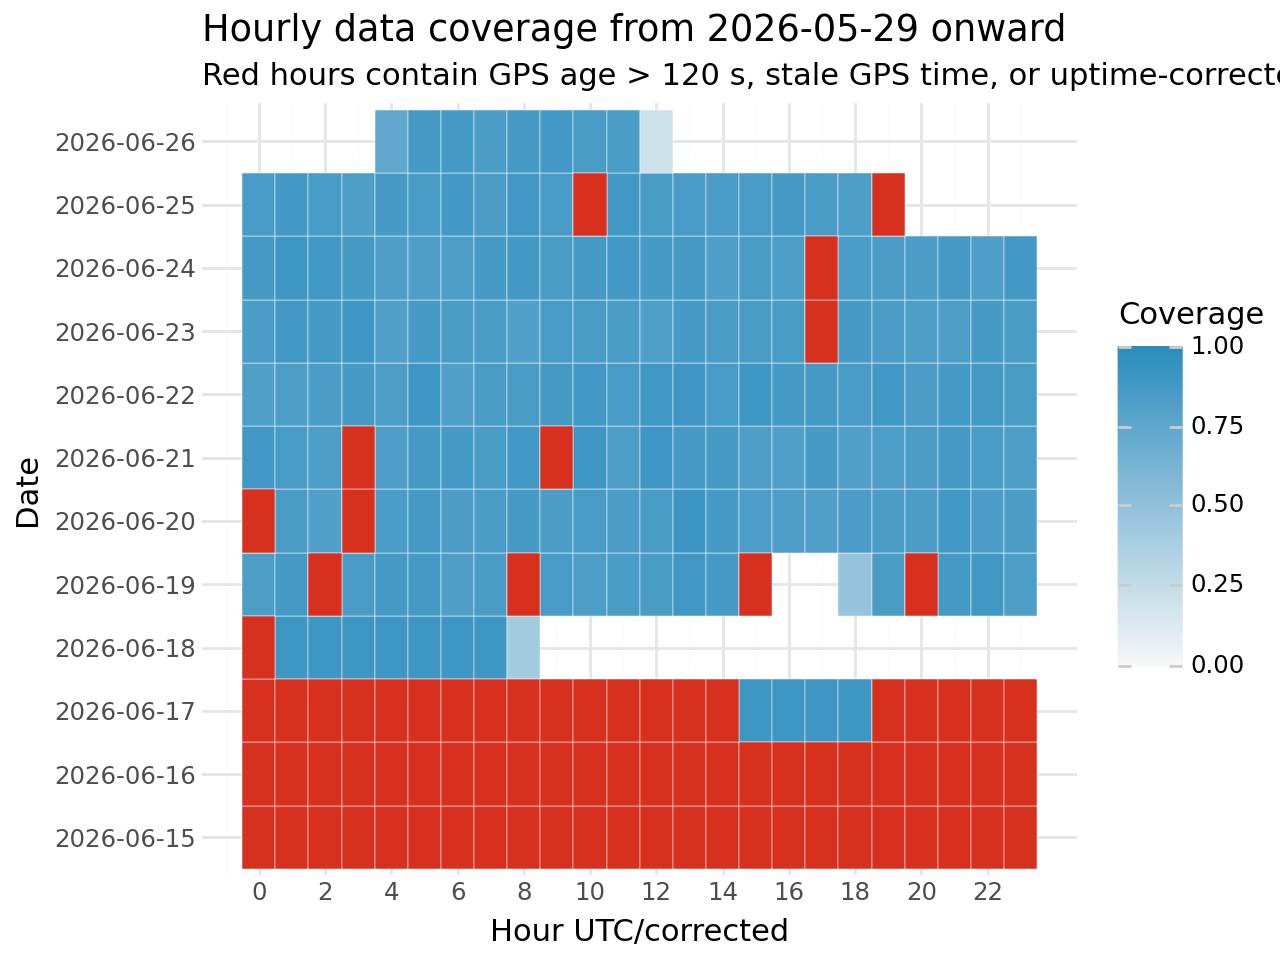

In [3]:
def sensor_long(df: pd.DataFrame, patterns: dict[str, str]) -> pd.DataFrame:
    frames = []
    for raw_col, label in patterns.items():
        if raw_col not in df.columns:
            continue
        tmp = df[["analysis_time", "date", "source_file", raw_col]].copy()
        tmp = tmp.rename(columns={raw_col: "value"})
        tmp["series"] = label
        tmp["value"] = pd.to_numeric(tmp["value"], errors="coerce")
        frames.append(tmp)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def save_plot(plot, filename: str, width: float = 9, height: float = 4.8):
    path = FIG_DIR / filename
    plot.save(path, width=width, height=height, units="in", dpi=150)
    print("saved", path)
    return plot


hourly_coverage = data.groupby(["date", "hour"], as_index=False).agg(
    rows=("analysis_time", "size"),
    unique_timestamps=("analysis_time", "nunique"),
    stale_gps_rows=("gps_time_stale", "sum"),
    corrected_from_uptime_rows=("time_corrected_from_uptime", "sum"),
    max_gps_age_ms=("gps_age_ms", lambda x: pd.to_numeric(x, errors="coerce").max()),
)
hourly_coverage["duplicate_timestamp_rows"] = hourly_coverage["rows"] - hourly_coverage["unique_timestamps"]
hourly_coverage["expected_rows"] = 3600 / EXPECTED_INTERVAL_SECONDS
hourly_coverage["coverage_fraction"] = (hourly_coverage["unique_timestamps"] / hourly_coverage["expected_rows"]).clip(upper=1)
hourly_coverage["stale_gps_fraction"] = hourly_coverage["stale_gps_rows"] / hourly_coverage["rows"]
hourly_coverage["has_stale_gps"] = hourly_coverage["stale_gps_rows"] > 0
stale_hourly_coverage = hourly_coverage[hourly_coverage["has_stale_gps"]].copy()

coverage_plot = (
    ggplot(hourly_coverage, aes("hour", "date", fill="coverage_fraction"))
    + geom_tile(color="white")
    + geom_tile(data=stale_hourly_coverage, mapping=aes("hour", "date"), fill="#d7301f", color="white")
    + scale_fill_gradient(low="#f7f7f7", high="#2b8cbe", limits=(0, 1))
    + scale_x_continuous(breaks=list(range(0, 24, 2)))
    + labs(
        title="Hourly data coverage from 2026-05-29 onward",
        subtitle="Red hours contain GPS age > 120 s, stale GPS time, or uptime-corrected timestamps",
        x="Hour UTC/corrected", y="Date", fill="Coverage"
    )
    + theme_minimal()
)
save_plot(coverage_plot, "hourly_coverage.png")

,source_file,previous_timestamp,analysis_time,gap_minutes
11086,data_20260617.csv,2026-06-17 14:00:19,2026-06-17 14:02:38,2.316667
12929,data_20260618.csv,2026-06-18 00:46:34,2026-06-18 00:49:25,2.850000
16931,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333
18450,data_20260620.csv,2026-06-20 03:13:46,2026-06-20 03:15:51,2.083333
18479,data_20260620.csv,2026-06-20 03:23:20,2026-06-20 03:25:35,2.250000


C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 9 x 4.8 in image.
C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: figures\inter_sample_gaps.png


saved figures\inter_sample_gaps.png


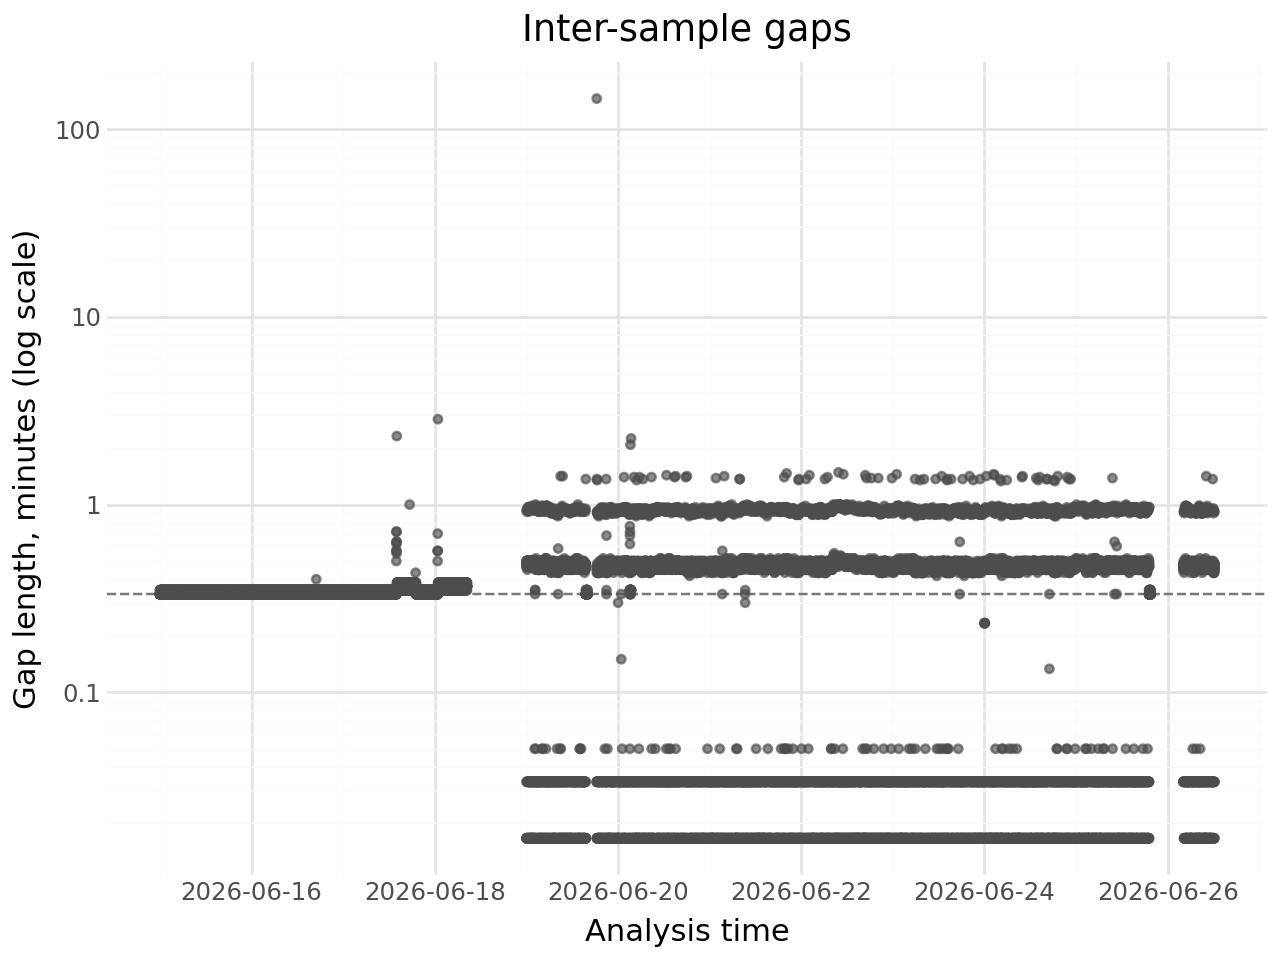

In [4]:
gap_rows = []
for source_file, group in data.groupby("source_file", sort=True):
    ts = group.sort_values("analysis_time")["analysis_time"].reset_index(drop=True)
    gap = pd.DataFrame({
        "source_file": source_file,
        "previous_timestamp": ts.shift(1),
        "analysis_time": ts,
        "delta_seconds": ts.diff().dt.total_seconds(),
    })
    gap_rows.append(gap)
gaps = pd.concat(gap_rows, ignore_index=True)
gaps["gap_minutes"] = gaps["delta_seconds"] / 60
large_gaps = gaps[gaps["delta_seconds"] > 120].copy()
large_gaps["date"] = large_gaps["analysis_time"].dt.strftime("%Y-%m-%d")

gap_plot_data = gaps.dropna(subset=["delta_seconds"]).query("delta_seconds > 0").copy()
gap_plot_data["date"] = gap_plot_data["analysis_time"].dt.strftime("%Y-%m-%d")
gap_plot_data["gap_minutes"] = gap_plot_data["delta_seconds"] / 60

gap_plot = (
    ggplot(gap_plot_data, aes("analysis_time", "gap_minutes"))
    + geom_hline(yintercept=EXPECTED_INTERVAL_SECONDS / 60, color="#777777", linetype="dashed")
    + geom_point(size=1.2, alpha=0.65, color="#4d4d4d")
    + scale_y_log10()
    + labs(title="Inter-sample gaps", x="Analysis time", y="Gap length, minutes (log scale)")
    + theme_minimal()
)
display(large_gaps[["source_file", "previous_timestamp", "analysis_time", "gap_minutes"]])
save_plot(gap_plot, "inter_sample_gaps.png")

,series,n,min_C,median_C,p95_C,max_C
0,BME280 bus0,30977,18.71,27.11,33.05,34.30
1,BME280 bus1,30983,18.40,26.84,34.71,35.81
2,SCD30 bus0,30995,0.00,31.06,40.53,42.85
3,SCD30 bus1,30997,20.42,31.37,45.21,47.66
4,SEN0465 bus0,14114,57.50,126.93,493.93,493.93
5,SEN0465 bus1,30977,20.24,31.43,44.72,201.03


C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 9 x 4.8 in image.
C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: figures\temperature_timeseries.png


saved figures\temperature_timeseries.png


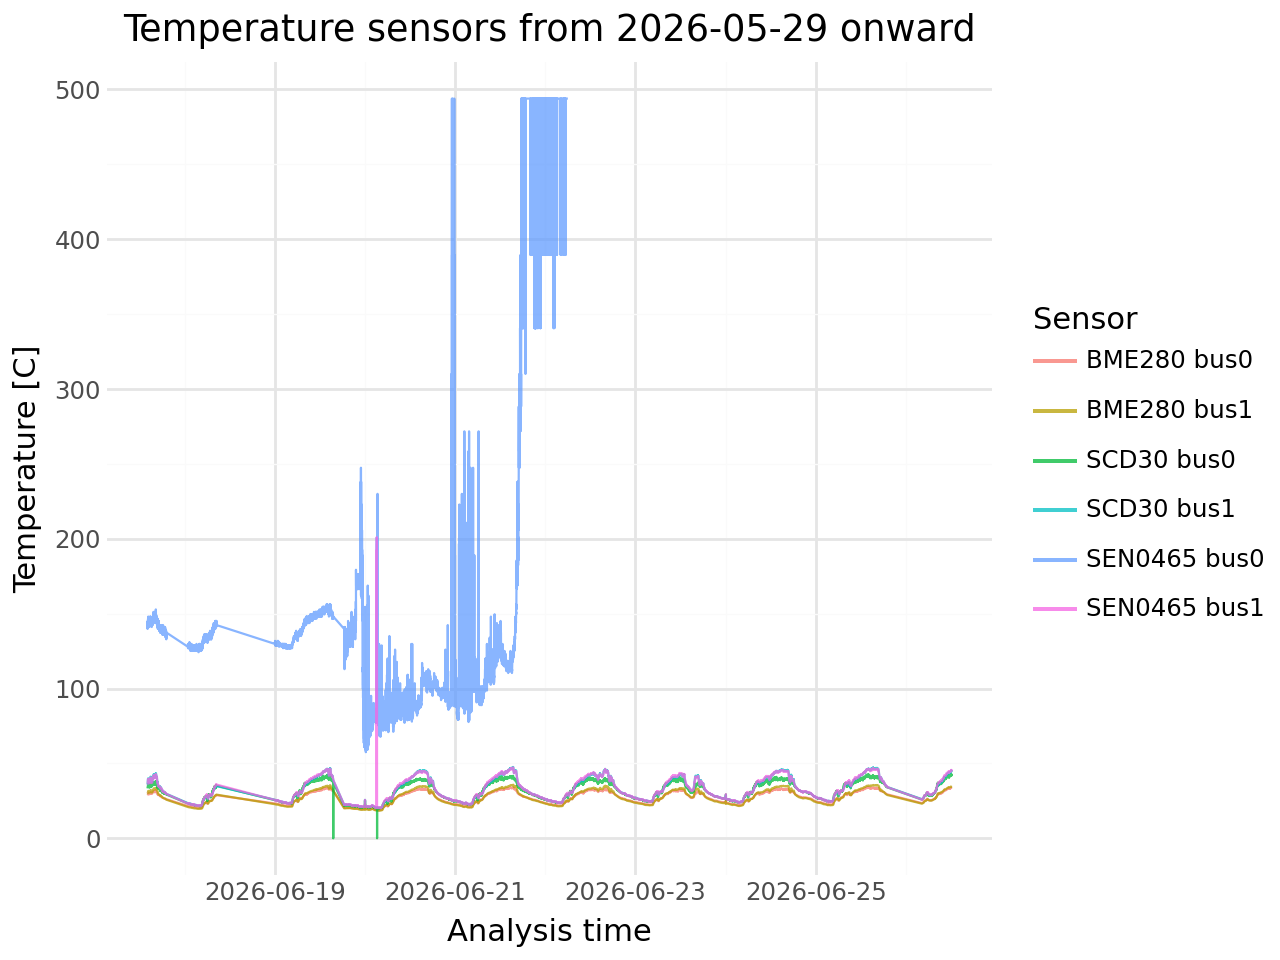

In [5]:
temperature_columns = {
    "bme_T.C__bus0": "BME280 bus0",
    "bme_T.C__bus1": "BME280 bus1",
    "scd_T.C__bus0": "SCD30 bus0",
    "scd_T.C__bus1": "SCD30 bus1",
    "sen_T.C__bus0": "SEN0465 bus0",
    "sen_T.C__bus1": "SEN0465 bus1",
}
temperature_long = sensor_long(data, temperature_columns)
temperature_long.loc[temperature_long["value"] <= -100, "value"] = np.nan
temperature_long = temperature_long.dropna(subset=["value"])

temperature_summary = temperature_long.groupby("series", as_index=False).agg(
    n=("value", "size"),
    min_C=("value", "min"),
    median_C=("value", "median"),
    p95_C=("value", lambda x: x.quantile(0.95)),
    max_C=("value", "max"),
)
display(temperature_summary)

temperature_plot = (
    ggplot(temperature_long, aes("analysis_time", "value", color="series"))
    + geom_line(alpha=0.75, size=0.45)
    + labs(title="Temperature sensors from 2026-05-29 onward", x="Analysis time", y="Temperature [C]", color="Sensor")
    + theme_minimal()
)
save_plot(temperature_plot, "temperature_timeseries.png")

C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 10 x 8 in image.
C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: figures\overview_variables.png


saved figures\overview_variables.png


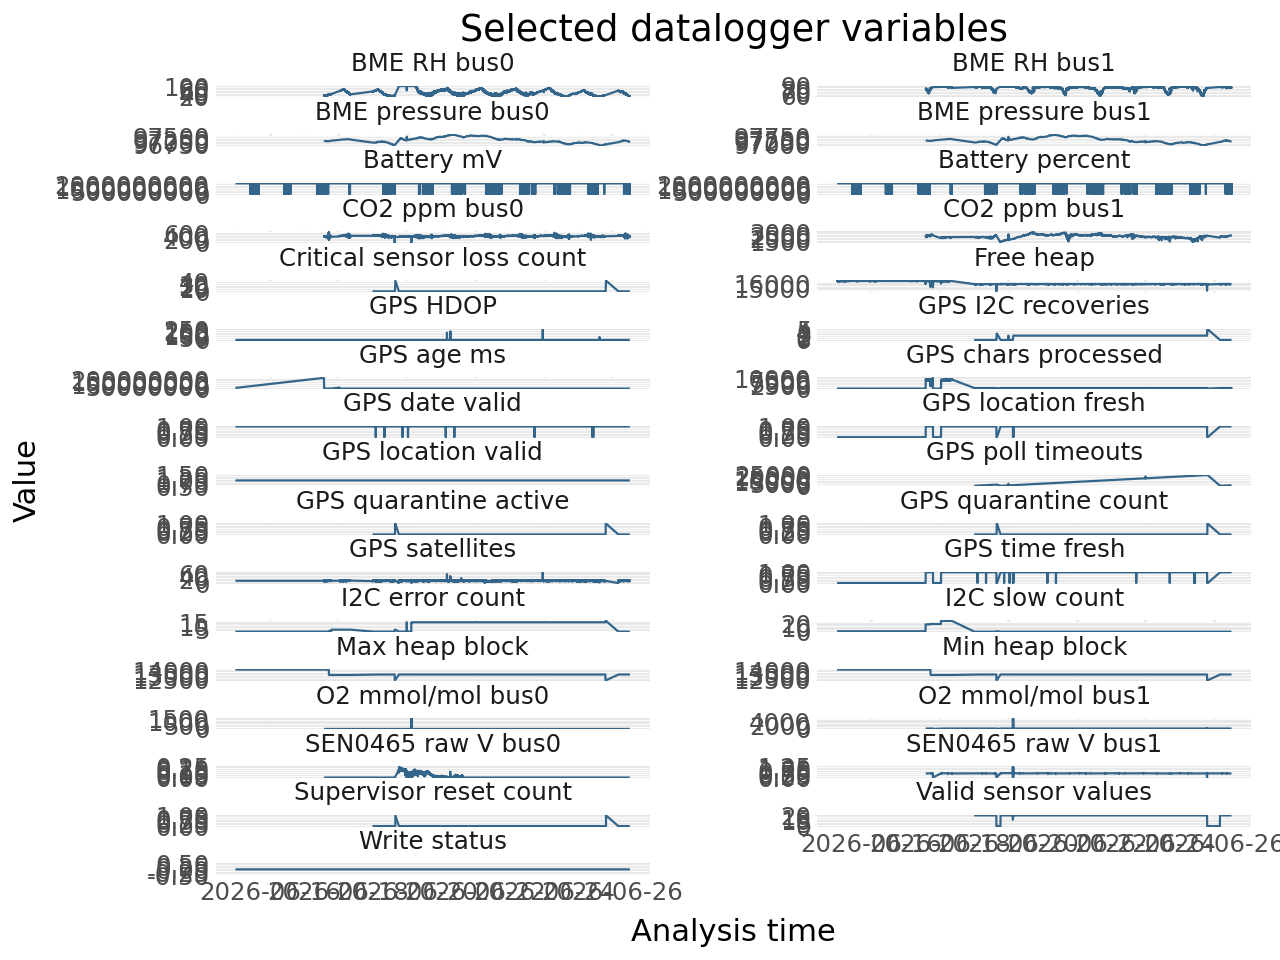

In [6]:
overview_columns = {
    "scd_CO2.ppm__bus0": "CO2 ppm bus0",
    "scd_CO2.ppm__bus1": "CO2 ppm bus1",
    "sen_O2.mmol_mol__bus0": "O2 mmol/mol bus0",
    "sen_O2.mmol_mol__bus1": "O2 mmol/mol bus1",
    "sen_raw_V__bus0": "SEN0465 raw V bus0",
    "sen_raw_V__bus1": "SEN0465 raw V bus1",
    "bme_RH.perc__bus0": "BME RH bus0",
    "bme_RH.perc__bus1": "BME RH bus1",
    "bme_P.Pa__bus0": "BME pressure bus0",
    "bme_P.Pa__bus1": "BME pressure bus1",
    "nb_sat": "GPS satellites",
    "HDOP": "GPS HDOP",
    "bat.mV": "Battery mV",
    "bat.perc": "Battery percent",
    "gps_date_valid": "GPS date valid",
    "gps_time_fresh": "GPS time fresh",
    "gps_location_fresh": "GPS location fresh",
    "gps_location_valid": "GPS location valid",
    "gps_chars_processed": "GPS chars processed",
    "gps_age_ms": "GPS age ms",
    "free_heap": "Free heap",
    "max_heap_block": "Max heap block",
    "min_heap_block": "Min heap block",
    "i2c_slow_count": "I2C slow count",
    "i2c_error_count": "I2C error count",
    "write_status": "Write status",
    "gps_poll_timeout_count": "GPS poll timeouts",
    "gps_i2c_recovery_count": "GPS I2C recoveries",
    "gps_quarantine_active": "GPS quarantine active",
    "gps_quarantine_count": "GPS quarantine count",
    "valid_sensor_value_count": "Valid sensor values",
    "critical_sensor_loss_count": "Critical sensor loss count",
    "gps_time_sane": "GPS time sane",
    "gps_rejected_time_count": "GPS rejected time count",
    "gps_i2c_hard_fault_count": "GPS/I2C hard fault count",
    "supervisor_reset_count": "Supervisor reset count",
}
overview_long = sensor_long(data, overview_columns).dropna(subset=["value"])

overview_plot = (
    ggplot(overview_long, aes("analysis_time", "value"))
    + geom_line(size=0.45, color="#33658a")
    + facet_wrap("series", scales="free_y", ncol=2)
    + labs(title="Selected datalogger variables", x="Analysis time", y="Value")
    + theme_minimal()
)
save_plot(overview_plot, "overview_variables.png", width=10, height=8)



In [7]:
def nearest_temperature_before_gap(large_gaps: pd.DataFrame, temperature_long: pd.DataFrame, window_minutes: int = 30) -> pd.DataFrame:
    records = []
    for _, gap in large_gaps.iterrows():
        start = gap["previous_timestamp"] - pd.Timedelta(minutes=window_minutes)
        end = gap["previous_timestamp"]
        window = temperature_long[(temperature_long["analysis_time"] >= start) & (temperature_long["analysis_time"] <= end)]
        for series, group in window.groupby("series"):
            records.append({
                "source_file": gap["source_file"],
                "gap_start": gap["previous_timestamp"],
                "gap_end": gap["analysis_time"],
                "gap_minutes": gap["gap_minutes"],
                "series": series,
                "max_temperature_C_before_gap": group["value"].max(),
                "median_temperature_C_before_gap": group["value"].median(),
                "n_temperature_rows": len(group),
            })
    return pd.DataFrame.from_records(records)


overheat_gap_check = nearest_temperature_before_gap(large_gaps, temperature_long)
display(overheat_gap_check.sort_values(["gap_start", "series"]))

if not overheat_gap_check.empty:
    print("Highest temperature observed in the 30 minutes before a >120 s gap:")
    display(overheat_gap_check.sort_values("max_temperature_C_before_gap", ascending=False).head(10))

,source_file,gap_start,gap_end,gap_minutes,series,max_temperature_C_before_gap,median_temperature_C_before_gap,n_temperature_rows
0,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333,BME280 bus0,31.93,31.735,10
1,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333,BME280 bus1,32.34,32.050,11
2,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333,SCD30 bus0,37.89,37.415,14
3,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333,SCD30 bus1,39.64,38.935,14
4,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333,SEN0465 bus0,148.06,146.570,11
5,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333,SEN0465 bus1,39.79,39.190,11
6,data_20260620.csv,2026-06-20 03:13:46,2026-06-20 03:15:51,2.083333,BME280 bus0,19.08,18.960,85
7,data_20260620.csv,2026-06-20 03:13:46,2026-06-20 03:15:51,2.083333,BME280 bus1,18.77,18.640,87
8,data_20260620.csv,2026-06-20 03:13:46,2026-06-20 03:15:51,2.083333,SCD30 bus0,20.31,20.120,92
9,data_20260620.csv,2026-06-20 03:13:46,2026-06-20 03:15:51,2.083333,SCD30 bus1,20.83,20.720,92


Highest temperature observed in the 30 minutes before a >120 s gap:


,source_file,gap_start,gap_end,gap_minutes,series,max_temperature_C_before_gap,median_temperature_C_before_gap,n_temperature_rows
16,data_20260620.csv,2026-06-20 03:23:20,2026-06-20 03:25:35,2.250000,SEN0465 bus0,230.00,81.650,82
11,data_20260620.csv,2026-06-20 03:13:46,2026-06-20 03:15:51,2.083333,SEN0465 bus1,201.03,20.640,84
10,data_20260620.csv,2026-06-20 03:13:46,2026-06-20 03:15:51,2.083333,SEN0465 bus0,201.03,81.350,85
17,data_20260620.csv,2026-06-20 03:23:20,2026-06-20 03:25:35,2.250000,SEN0465 bus1,201.03,20.540,80
4,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333,SEN0465 bus0,148.06,146.570,11
5,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333,SEN0465 bus1,39.79,39.190,11
3,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333,SCD30 bus1,39.64,38.935,14
2,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333,SCD30 bus0,37.89,37.415,14
1,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333,BME280 bus1,32.34,32.050,11
0,data_20260619.csv,2026-06-19 15:59:57,2026-06-19 18:25:26,145.483333,BME280 bus0,31.93,31.735,10


In [8]:
# Future-date checks and GPS/I2C restart diagnostics.
def status_file_date(path: Path) -> str:
    match = re.fullmatch(r"status_(\d{8})\.csv", path.name)
    return match.group(1) if match else ""


def read_status_file(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path, na_values=["", "nan", "NaN", "NAN"], keep_default_na=True, on_bad_lines="skip")
    frame.insert(0, "source_file", path.name)
    frame.insert(1, "source_date", status_file_date(path))
    return frame


def real_sensor_columns(df: pd.DataFrame) -> list[str]:
    prefixes = ("bme_", "scd_", "sen_", "Sin.", "Sout.", "mlx_")
    blocked = ("flag", ".cal")
    return [col for col in df.columns if col.startswith(prefixes) and not any(token in col for token in blocked)]


status_files = sorted(path for path in DATA_DIR.glob("status_*.csv") if "20260611" <= status_file_date(path) <= ANALYSIS_END_DATE)
if status_files:
    status_data = pd.concat([read_status_file(path) for path in status_files], ignore_index=True, sort=False)
    for col in status_data.columns:
        if col not in {"source_file", "source_date", "event", "reset_reason", "CRC16", "boot_time_source", "supervisor_restart_reason"}:
            status_data[col] = pd.to_numeric(status_data[col], errors="coerce")
else:
    status_data = pd.DataFrame()

sensor_cols = real_sensor_columns(data)
for col in sensor_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")
if "valid_sensor_value_count" not in data.columns:
    data["valid_sensor_value_count"] = data[sensor_cols].notna().sum(axis=1) if sensor_cols else 0
if "missing_sensor_value_count" not in data.columns:
    data["missing_sensor_value_count"] = data[sensor_cols].isna().sum(axis=1) if sensor_cols else 0

for col in [
    "gps_chars_processed", "gps_age_ms", "gps_time_fresh", "gps_time_sane",
    "gps_quarantine_active", "critical_sensor_loss_count", "gps_i2c_hard_fault_count",
    "supervisor_reset_count", "gps_rejected_time_count",
]:
    if col not in data.columns:
        data[col] = pd.NA
    data[col] = pd.to_numeric(data[col], errors="coerce")

source_dates = pd.to_datetime(data["source_date"], format="%Y%m%d", errors="coerce")
future_file_summary = future_rows_dropped_summary.copy()
print("Future-dated data rows dumped before analysis:")
display(future_file_summary)

classified = data.dropna(subset=["analysis_time"]).copy()
valid_sensor_values = pd.to_numeric(classified["valid_sensor_value_count"], errors="coerce").fillna(0)
gps_chars = pd.to_numeric(classified["gps_chars_processed"], errors="coerce")
gps_age = pd.to_numeric(classified["gps_age_ms"], errors="coerce")
gps_fresh = pd.to_numeric(classified["gps_time_fresh"], errors="coerce").fillna(1)
gps_sane = pd.to_numeric(classified["gps_time_sane"], errors="coerce").fillna(1)
gps_quarantine = pd.to_numeric(classified["gps_quarantine_active"], errors="coerce").fillna(0).astype(bool)
hard_fault_counter = pd.to_numeric(classified["gps_i2c_hard_fault_count"], errors="coerce").fillna(0)
supervisor_counter = pd.to_numeric(classified["supervisor_reset_count"], errors="coerce").fillna(0)
rejected_counter = pd.to_numeric(classified["gps_rejected_time_count"], errors="coerce").fillna(0)

classified["gps_dead"] = (gps_fresh.eq(0) | gps_age.gt(GPS_STALE_THRESHOLD_MS)) & gps_chars.fillna(1).eq(0)
classified["sensor_data_lost"] = valid_sensor_values.eq(0)
classified["gps_time_rejected"] = gps_sane.eq(0) & gps_fresh.eq(1)
classified["supervisor_restart"] = supervisor_counter.gt(0)
classified["gps_i2c_hard_fault"] = classified["sensor_data_lost"] & (gps_quarantine | classified["gps_dead"] | hard_fault_counter.gt(0))
classified["boot_waiting_for_gps"] = classified["sensor_data_lost"] & classified["analysis_time"].isna()
classified["fault_class"] = np.select(
    [
        classified["supervisor_restart"],
        classified["gps_i2c_hard_fault"],
        classified["gps_time_rejected"] | rejected_counter.gt(0),
        classified["sensor_data_lost"],
        classified["gps_dead"],
        gps_fresh.eq(0) | gps_age.gt(GPS_STALE_THRESHOLD_MS),
    ],
    ["supervisor_restart", "gps_i2c_hard_fault", "gps_time_rejected", "sensor_data_lost", "gps_dead", "gps_stale_only"],
    default="normal",
)

fault_summary = (
    classified.assign(date=lambda x: x["analysis_time"].dt.strftime("%Y-%m-%d"))
    .groupby(["date", "fault_class"], as_index=False)
    .agg(
        rows=("fault_class", "size"),
        first_time=("analysis_time", "min"),
        last_time=("analysis_time", "max"),
        min_valid_sensor_values=("valid_sensor_value_count", "min"),
        max_gps_age_ms=("gps_age_ms", "max"),
        max_hard_fault_count=("gps_i2c_hard_fault_count", "max"),
        max_supervisor_reset_count=("supervisor_reset_count", "max"),
    )
)
print("GPS/I2C fault classification summary:")
display(fault_summary)

transitions = classified[[
    "analysis_time", "fault_class", "valid_sensor_value_count",
    "gps_chars_processed", "gps_age_ms", "source_file",
]].copy()
transitions["group"] = transitions["fault_class"].ne(transitions["fault_class"].shift()).cumsum()
fault_intervals = (
    transitions.groupby("group", as_index=False)
    .agg(
        fault_class=("fault_class", "first"),
        start=("analysis_time", "min"),
        end=("analysis_time", "max"),
        rows=("fault_class", "size"),
        min_valid_sensor_values=("valid_sensor_value_count", "min"),
        max_gps_age_ms=("gps_age_ms", "max"),
        first_source_file=("source_file", "first"),
        last_source_file=("source_file", "last"),
    )
)
fault_intervals["duration_minutes"] = (fault_intervals["end"] - fault_intervals["start"]).dt.total_seconds() / 60
fault_intervals = fault_intervals[fault_intervals["fault_class"] != "normal"]
print("Fault intervals:")
display(fault_intervals.sort_values("start"))

if not status_data.empty:
    status_events = status_data[status_data["event"].astype(str).str.contains(
        "boot|gps|sensor_data_lost|supervisor", case=False, na=False
    )].copy()
    print("Important status events:")
    display(status_events)

    restart_events = status_data[status_data["event"].eq("supervisor_restart_pending")].copy()
    boot_events = status_data[status_data["event"].eq("boot")].copy()
    restart_records = []
    for _, restart in restart_events.iterrows():
        later_boots = boot_events[
            (boot_events["source_date"] >= restart["source_date"]) &
            (boot_events["boot_id"] != restart.get("boot_id"))
        ]
        next_boot = later_boots.head(1)
        restart_records.append({
            "restart_source_file": restart["source_file"],
            "restart_sample_counter": restart.get("sample_counter"),
            "restart_uptime_ms": restart.get("uptime_ms"),
            "restart_reason": restart.get("supervisor_restart_reason", ""),
            "next_boot_file": next_boot["source_file"].iloc[0] if len(next_boot) else pd.NA,
            "next_boot_id": next_boot["boot_id"].iloc[0] if len(next_boot) else pd.NA,
            "next_boot_reset_reason": next_boot["reset_reason"].iloc[0] if len(next_boot) else pd.NA,
        })
    restart_summary = pd.DataFrame.from_records(restart_records)
    print("Supervisor restart follow-up:")
    display(restart_summary)
else:
    print("No status data available for restart diagnostics.")


if not fault_intervals.empty:
    fault_timeline_plot = (
        ggplot(fault_intervals, aes(x="start", xend="end", y="fault_class", yend="fault_class", color="fault_class"))
        + geom_segment(size=6)
        + scale_color_manual(values={
            "gps_i2c_hard_fault": "#b2182b",
            "supervisor_restart": "#111111",
            "gps_time_rejected": "#e66101",
            "sensor_data_lost": "#fc8d59",
            "gps_dead": "#756bb1",
            "gps_stale_only": "#8073ac",
        })
        + labs(title="GPS/I2C hard-fault and restart timeline", x="Analysis time", y="Fault class", color="Fault class")
        + theme_minimal()
    )
    save_plot(fault_timeline_plot, "gps_i2c_fault_timeline.png", width=10, height=3.5)


Future-dated data rows dumped before analysis:


,source_file,source_date,rows,first_time,last_time
0,data_20260630.csv,20260630,1,NaT,NaT
1,data_20461231.csv,20461231,1,NaT,NaT


GPS/I2C fault classification summary:


,date,fault_class,rows,first_time,last_time,min_valid_sensor_values,max_gps_age_ms,max_hard_fault_count,max_supervisor_reset_count
0,2026-06-15,gps_i2c_hard_fault,4295,2026-06-15 00:00:02,2026-06-15 23:59:59,NaN,100971136,NaN,NaN
1,2026-06-16,gps_i2c_hard_fault,4293,2026-06-16 00:00:20,2026-06-16 23:59:57,NaN,187368703,NaN,NaN
2,2026-06-17,gps_i2c_hard_fault,3369,2026-06-17 00:00:17,2026-06-17 23:59:58,NaN,237791162,NaN,NaN
3,2026-06-17,sensor_data_lost,836,2026-06-17 14:02:38,2026-06-17 19:07:53,NaN,102468,NaN,NaN
4,2026-06-18,gps_i2c_hard_fault,136,2026-06-18 00:00:18,2026-06-18 00:46:34,NaN,20423666,NaN,NaN
5,2026-06-18,sensor_data_lost,1249,2026-06-18 00:49:25,2026-06-18 08:27:24,NaN,265,NaN,NaN
6,2026-06-19,gps_i2c_hard_fault,76,2026-06-19 15:34:27,2026-06-19 15:59:37,0.0,1637287,NaN,0.0
7,2026-06-19,gps_stale_only,6,2026-06-19 02:16:56,2026-06-19 20:58:23,20.0,41911,NaN,0.0
8,2026-06-19,normal,3625,2026-06-19 00:00:45,2026-06-19 23:59:47,12.0,86193,NaN,0.0
9,2026-06-19,sensor_data_lost,4,2026-06-19 15:34:07,2026-06-19 18:25:28,0.0,107129,NaN,0.0


Fault intervals:


...

,source_file,source_date,event,boot_id,sample_counter,uptime_ms,reset_reason,free_heap,max_heap_block,min_heap_block,...,i2c_error_count,i2c_recovery_count,gps_poll_timeout_count,gps_i2c_recovery_count,gps_quarantine_active,gps_quarantine_count,valid_sensor_value_count,missing_sensor_value_count,critical_sensor_loss_count,supervisor_reset_count
0,status_20260611.csv,20260611,boot,11901737,1,22792,Power On,17344,14736,14736,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,status_20260614.csv,20260614,gps_stale,11898506,12712,279752400,Power On,16792,14192,14192,...,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1578,status_20260617.csv,20260617,gps_recovered,11898506,24514,517403687,Power On,16752,14192,14192,...,2.0,1576.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1582,status_20260617.csv,20260617,gps_stale,11898506,25352,535920545,Power On,16672,13304,13304,...,5.0,1580.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1650,status_20260618.csv,20260618,gps_recovered,11898506,26357,556210007,Power On,16560,13304,13304,...,5.0,1714.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1653,status_20260619.csv,20260619,gps_stale,11918449,2755,79650366,Software/System restart,15880,12496,12496,...,5.0,4.0,2696.0,1.0,0.0,0.0,0.0,20.0,0.0,0.0
1654,status_20260619.csv,20260619,gps_i2c_stale,11918449,2755,79650413,Software/System restart,15880,12496,12496,...,5.0,4.0,2696.0,1.0,0.0,0.0,0.0,20.0,0.0,0.0
1655,status_20260619.csv,20260619,gps_i2c_recovery,11918449,2755,79650459,Software/System restart,15880,12496,12496,...,5.0,4.0,2696.0,1.0,0.0,0.0,0.0,20.0,0.0,0.0
1657,status_20260619.csv,20260619,gps_i2c_recovery,11918449,2770,79952426,Software/System restart,15880,12496,12496,...,5.0,6.0,2696.0,2.0,0.0,0.0,0.0,20.0,0.0,0.0
1659,status_20260619.csv,20260619,gps_i2c_recovery,11918449,2785,80254400,Software/System restart,15880,12496,12496,...,5.0,8.0,2696.0,3.0,1.0,1.0,0.0,20.0,1.0,0.0


Supervisor restart follow-up:


,restart_source_file,restart_sample_counter,restart_uptime_ms,restart_reason,next_boot_file,next_boot_id,next_boot_reset_reason
0,status_20260619.csv,2829,81140273,,status_20260619.csv,11917989,Software/System restart
1,status_20260625.csv,24937,531145672,,status_20260626.csv,11904844,Software/System restart


saved figures\gps_i2c_fault_timeline.png


C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 10 x 3.5 in image.
C:\Users\jonmuell\AppData\Local\miniconda3\envs\dp\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: figures\gps_i2c_fault_timeline.png
